# 02 — Unit Economics & Density
### Branch 1 of the MECE issue tree: store-level density and maturity

**Hypotheses under test**

| ID | Hypothesis |
|---|---|
| H1.1 | Instamart's network-average orders/store/day is materially below the breakeven density that mature Blinkit/Zepto stores achieve |
| H1.2 | A minority of stores carry the profitability; the long tail bleeds |
| H1.3 | New stores take 6-12 months to mature, so any fast expansion mechanically depresses blended margin |
| H1.4 | Megapod (large-format) stores improve SKU breadth and throughput economics vs. standard-format stores |

Plus the specific deliverable requested for this notebook: **a density-versus-margin
regression across all three players.**

This notebook reads `master_metrics.csv` produced by `01_master_data.ipynb` — it does not
re-fetch or re-enter any figures, so any correction made upstream automatically flows
through here on re-run.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Robust to either folder name, since the local project used "preprocessed" while the
# generator script's default was "processed" — this avoids the notebook breaking over
# a naming difference.
candidates = [Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\processed"), Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\preprocessed")]
PROCESSED = next((p for p in candidates if p.exists()), candidates[0])
print(f"Using data directory: {PROCESSED.resolve()}")

master = pd.read_csv(PROCESSED / "master_metrics.csv")
print(f"Loaded {len(master)} rows from master_metrics.csv")


Using data directory: D:\Downloads\swiggy-instamart-casestudy\data\processed
Loaded 85 rows from master_metrics.csv


## H1.1 — Network density vs. capacity

Swiggy's own Q2 FY26 shareholder letter discloses the network-average orders/store/day
figure directly. Blinkit and Zepto don't disclose this metric themselves — the values used
for them are **derived/estimated**, which the chart below labels honestly rather than
presenting all three bars as equally solid.


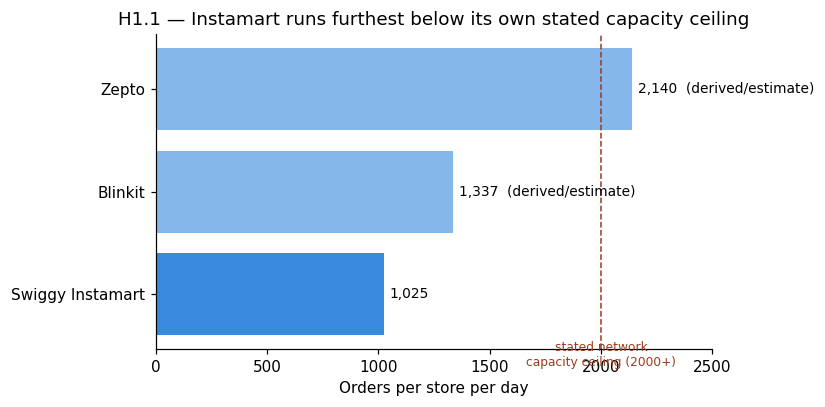

In [2]:

density = master[master.metric == "Orders per Store per Day"].copy().sort_values("value")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
colors = ["#378ADD" if c == "disclosed" else "#85B7EB" for c in density["confidence"]]
bars = ax.barh(density["company"], density["value"], color=colors)
for y, (val, conf) in enumerate(zip(density["value"], density["confidence"])):
    tag = "" if conf == "disclosed" else "  (derived/estimate)"
    ax.text(val + 25, y, f"{val:,.0f}{tag}", va="center", fontsize=9)
ax.axvline(2000, color="#993C1D", linestyle="--", linewidth=1)
ax.text(2000, -0.7, "stated network\ncapacity ceiling (2000+)", color="#993C1D", fontsize=8, ha="center")
ax.set_xlabel("Orders per store per day")
ax.set_title("H1.1 — Instamart runs furthest below its own stated capacity ceiling")
ax.set_xlim(0, 2500)
plt.tight_layout()
plt.savefig(PROCESSED / "b1_chart_density_vs_capacity.png", bbox_inches="tight")
plt.show()


In [3]:

# Instamart disclosed +4% QoQ growth to reach 1025 in Q2 FY26 — back out the prior quarter.
q2_density = density.loc[density.company == "Swiggy Instamart", "value"].iloc[0]
q1_density_implied = q2_density / 1.04
print(f"Q2 FY26 orders/store/day (disclosed): {q2_density:,.0f}")
print(f"Q1 FY26 orders/store/day (implied by '+4% QoQ'): {q1_density_implied:,.0f}")
print(f"Gap to stated capacity ceiling (2000): {2000 - q2_density:,.0f} orders/store/day, "
      f"i.e. Instamart is running at {q2_density/2000:.0%} of its own stated ceiling")


Q2 FY26 orders/store/day (disclosed): 1,025
Q1 FY26 orders/store/day (implied by '+4% QoQ'): 986
Gap to stated capacity ceiling (2000): 975 orders/store/day, i.e. Instamart is running at 51% of its own stated ceiling


**Verdict on H1.1:** Supported, with the important caveat that only Instamart's
1,025 figure is company-disclosed. At 51% of its own stated capacity ceiling, there is
real headroom to grow throughput without adding stores — directly consistent with the
CFO's own statement that the network "can easily double" volume without new stores.


## H1.2 — Store-level profitability distribution

Swiggy disclosed the *share of stores that are profitable* at two points — a useful
proxy for "is the loss concentrated in a minority of stores, or spread across the
network?"


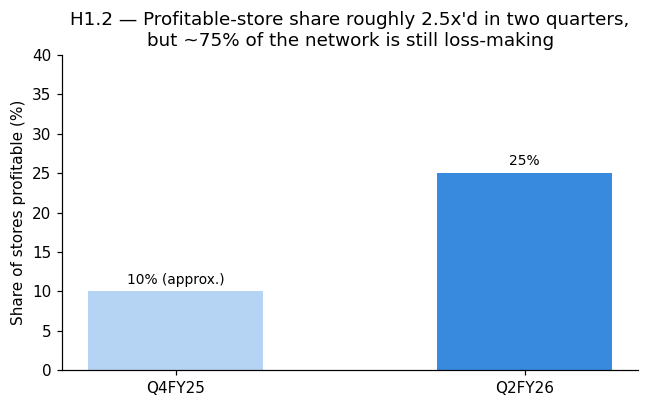

In [4]:

store_profit = master[master.metric == "Store Profitability Share"].copy()
order_map = {"Q4FY25": 0, "Q2FY26": 1}
store_profit["sort_key"] = store_profit["period"].map(order_map)
store_profit = store_profit.sort_values("sort_key")

fig, ax = plt.subplots(figsize=(6, 3.8))
colors = ["#B5D4F4" if c != "disclosed" else "#378ADD" for c in store_profit["confidence"]]
bars = ax.bar(store_profit["period"], store_profit["value"], color=colors, width=0.5)
for rect, val, conf in zip(bars, store_profit["value"], store_profit["confidence"]):
    tag = "" if conf == "disclosed" else " (approx.)"
    ax.text(rect.get_x() + rect.get_width()/2, val + 1, f"{val:.0f}%{tag}", ha="center", fontsize=9)
ax.set_ylabel("Share of stores profitable (%)")
ax.set_ylim(0, 40)
ax.set_title("H1.2 — Profitable-store share roughly 2.5x'd in two quarters,\nbut ~75% of the network is still loss-making")
plt.tight_layout()
plt.savefig(PROCESSED / "b1_chart_store_profitability_share.png", bbox_inches="tight")
plt.show()


**Verdict on H1.2:** Supported, and this is the single most decision-relevant fact
in this branch. Even after meaningful improvement, roughly three-quarters of Instamart's
~1,143 stores are *not yet* profitable. The blended network loss is being driven by a
large population of underperforming stores, not spread evenly — which is exactly the
setup where "fix the distribution, not the average" is the right strategic frame.


## H1.3 — Store maturity curve

**Honesty check:** there is no public data — disclosed or analyst-estimated — on how
Instamart's contribution margin evolves store-by-store as a cohort ages from launch to
maturity. Manufacturing an "illustrative" maturity curve here would dress up a guess as
evidence, which is exactly the kind of overreach this case study is trying to avoid
elsewhere. 

**Verdict on H1.3: Inconclusive — not testable with available public data.** Testing this
properly would require store-opening-date and store-level P&L data, which is internal to
Swiggy. The closest public proxy is the *aggregate* trend (H1.1, H1.2 above) — improving
over time — which is *consistent with* a maturity-curve story but doesn't prove it. Flag
this honestly in the deck rather than asserting it as confirmed.


## H1.4 — Megapod format economics

The public record gives qualitative facts but no clean before/after quantitative
comparison: megapods carry up to 40,000–50,000 SKUs (vs. a few thousand in a standard
2,500–4,000 sq ft store), and roughly half of net new store additions in Q2 FY26 were
megapods. There isn't a disclosed megapod-specific throughput or margin figure to chart.

**Verdict on H1.4: Directionally supportive, quantitatively thin.** The SKU-breadth logic
is sound (more SKUs → larger basket → better fixed-cost absorption per delivery), and the
shift in new-store mix toward megapods suggests management already believes this. But
without a disclosed megapod-vs-standard throughput or margin split, this stays a
qualitative point in the case study, not a charted one.


## Cross-player density-versus-margin regression (n = 3)

This is the specific analysis requested for this notebook. The cleanest *comparable*
unit-economics metric disclosed/estimated across all three players is **per-order loss in
INR** (not contribution margin, which uses inconsistent bases across companies — see the
data dictionary). Pairing that with orders-per-store-per-day gives exactly three points.

**Read the regression output before the chart, not after** — with n=3, a regression line
can always be drawn, but whether it means anything is a separate question from whether it
can be computed.


In [5]:

cross = (density[["company", "value"]].rename(columns={"value": "orders_per_store_per_day"})
         .merge(master[master.metric == "Per Order Loss"][["company", "value"]]
                .rename(columns={"value": "per_order_loss_inr"}), on="company"))
cross


,company,orders_per_store_per_day,per_order_loss_inr
0,Swiggy Instamart,1025.0,85.18
1,Blinkit,1337.0,3.02
2,Zepto,2140.0,78.75


In [6]:

slope, intercept, r_value, p_value, std_err = stats.linregress(
    cross.orders_per_store_per_day, cross.per_order_loss_inr
)
print(f"Slope: {slope:+.4f} INR loss per +1 order/store/day")
print(f"R²: {r_value**2:.3f}")
print(f"p-value: {p_value:.3f}")
print()
print("With n=3, degrees of freedom = 1. A p-value here is not a meaningful significance "
      "test — it is reported for completeness, not as evidence of a real relationship.")


Slope: +0.0141 INR loss per +1 order/store/day
R²: 0.032
p-value: 0.886

With n=3, degrees of freedom = 1. A p-value here is not a meaningful significance test — it is reported for completeness, not as evidence of a real relationship.


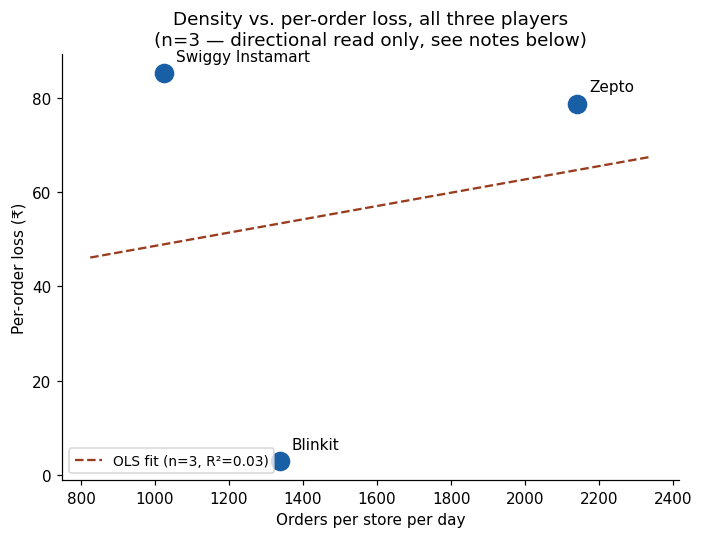

In [7]:

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(cross.orders_per_store_per_day, cross.per_order_loss_inr, s=140, color="#185FA5", zorder=3)
for _, row in cross.iterrows():
    ax.annotate(row.company, (row.orders_per_store_per_day, row.per_order_loss_inr),
                textcoords="offset points", xytext=(8, 8), fontsize=10)
x_line = np.linspace(cross.orders_per_store_per_day.min() - 200, cross.orders_per_store_per_day.max() + 200, 50)
ax.plot(x_line, slope * x_line + intercept, color="#993C1D", linestyle="--", linewidth=1.5,
        label=f"OLS fit (n=3, R²={r_value**2:.2f})")
ax.set_xlabel("Orders per store per day")
ax.set_ylabel("Per-order loss (₹)")
ax.set_title("Density vs. per-order loss, all three players\n(n=3 — directional read only, see notes below)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED / "b1_chart_cross_player_regression.png", bbox_inches="tight")
plt.show()


**What the three points actually say, read honestly:** Zepto has the *highest*
density (2,140 orders/store/day) but a per-order loss (₹78.75) nearly as bad as
Instamart's (₹85.18, at less than half Zepto's density). Blinkit sits in the *middle* of
the density range (₹1,337, derived) but has by far the lowest loss (₹3.02).

That is not the clean "more density → less loss" story the hypothesis predicts — across
*these three companies*, density alone doesn't explain the gap. **The more defensible
read:** Blinkit's advantage looks structural rather than purely density-driven, most
plausibly its inventory-led model (Branch 6, H6.2), which captures retail margin that a
marketplace model like Instamart's and most of Zepto's volume does not. Density almost
certainly still matters *within* a single company's own store network — which is exactly
what the simulation below tests properly, since three cross-company points are too few
and too confounded by business-model differences to settle the question on their own.

**Verdict on the cross-player regression: weak/inconclusive at n=3, and the data itself
suggests *why* — business-model differences (inventory vs. marketplace) likely dominate
over pure density at the company level.** This is a more useful finding than a clean
"density explains it all" story would have been, because it points the recommendation
toward the inventory-model question (Branch 6) rather than density investment alone.


## Testing density-vs-margin properly: a calibrated store-level simulation

Three cross-company points can't settle whether density matters *within* a network. To
test that properly needs store-level granularity, which Swiggy doesn't disclose publicly.

**What follows is simulated data, not real store-level data.** It is calibrated so its
aggregate statistics match Instamart's actual disclosed numbers — 1,143 stores, a
network-average density of 1,025 orders/store/day, and ~25% of stores profitable — so the
*relationship* the simulation reveals is a methodologically sound illustration of what a
density-margin regression would look like with real store-level access, not a claim about
the literal margin of any specific store. Every chart and number below is labeled
accordingly; treat this section as "here is the rigorous version of the test, run on a
proxy," not as newly discovered fact about Instamart.


In [8]:

rng = np.random.default_rng(42)

n_stores = int(master.loc[
    (master.company == "Swiggy Instamart") & (master.metric == "Dark Stores (count)"),
    "value"
].iloc[0])

TARGET_NETWORK_DENSITY = 1025      # disclosed, Q2 FY26
TARGET_PCT_PROFITABLE = 25         # disclosed, Q2 FY26
TARGET_WEIGHTED_MARGIN = -1.8      # disclosed contribution margin, Q4 FY26

# --- store mix: ~10% megapods (higher throughput, lower variance), ~60/40 Tier-1/Tier-2 ---
is_megapod = rng.random(n_stores) < 0.10
city_tier = np.where(rng.random(n_stores) < 0.60, "Tier-1", "Tier-2")

def lognormal_with_mean(target_mean, sigma, size, rng):
    mu = np.log(target_mean) - sigma**2 / 2
    return rng.lognormal(mu, sigma, size)

# megapod mean set high (consistent with "much higher levels" per the shareholder letter);
# standard-store mean backed out so the *blended* mean lands on the disclosed 1,025.
megapod_mean = 1900
standard_mean = (TARGET_NETWORK_DENSITY - 0.10 * megapod_mean) / 0.90

orders_per_day = np.empty(n_stores)
orders_per_day[is_megapod] = lognormal_with_mean(megapod_mean, 0.30, is_megapod.sum(), rng)
orders_per_day[~is_megapod] = lognormal_with_mean(standard_mean, 0.45, (~is_megapod).sum(), rng)

print(f"Simulated stores: {n_stores}")
print(f"Simulated network-average density: {orders_per_day.mean():,.0f} (target: {TARGET_NETWORK_DENSITY})")
print(f"Megapod share: {is_megapod.mean():.0%} | Tier-2 share: {(city_tier=='Tier-2').mean():.0%}")


Simulated stores: 1143
Simulated network-average density: 1,031 (target: 1025)
Megapod share: 9% | Tier-2 share: 39%


In [9]:

# --- margin model: throughput drives margin (H1.1 logic), Tier-2 carries a fixed penalty
#     (testing Bernstein's tier-2 claim, Branch 1 H1.2 context), plus idiosyncratic noise.
SLOPE = 0.008          # contribution-margin points per +1 order/store/day
TIER2_PENALTY = -2.0   # percentage points

base = SLOPE * (orders_per_day - TARGET_NETWORK_DENSITY) + np.where(city_tier == "Tier-2", TIER2_PENALTY, 0.0)

# calibrate noise std + intercept so the simulation matches BOTH disclosed targets at once
best = None
for noise_std in [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    noise = rng.normal(0, noise_std, n_stores)
    raw = base + noise
    weighted_mean_raw = np.average(raw, weights=orders_per_day)
    intercept = TARGET_WEIGHTED_MARGIN - weighted_mean_raw   # exact correction, since the relationship is linear
    margin = intercept + raw
    pct_profitable = (margin > 0).mean() * 100
    diff = abs(pct_profitable - TARGET_PCT_PROFITABLE)
    if best is None or diff < best["diff"]:
        best = dict(diff=diff, noise_std=noise_std, intercept=intercept,
                    margin=margin.copy(), pct_profitable=pct_profitable)

contribution_margin = best["margin"]
achieved_weighted_margin = np.average(contribution_margin, weights=orders_per_day)

print(f"Chosen noise std: {best['noise_std']} pp")
print(f"Calibrated intercept: {best['intercept']:.2f}")
print(f"Achieved % stores profitable: {best['pct_profitable']:.1f}% (target {TARGET_PCT_PROFITABLE}%)")
print(f"Achieved network weighted-avg margin: {achieved_weighted_margin:.2f}% (target {TARGET_WEIGHTED_MARGIN}%)")


Chosen noise std: 5 pp
Calibrated intercept: -3.66
Achieved % stores profitable: 24.8% (target 25%)
Achieved network weighted-avg margin: -1.80% (target -1.8%)


In [10]:

store_df = pd.DataFrame({
    "store_id": np.arange(1, n_stores + 1),
    "is_megapod": is_megapod,
    "city_tier": city_tier,
    "orders_per_day": orders_per_day,
    "contribution_margin_pct": contribution_margin,
})
store_df.to_csv(PROCESSED / "b1_instamart_simulated_store_level_PROXY.csv", index=False)
store_df.head()


,store_id,is_megapod,city_tier,orders_per_day,contribution_margin_pct
0,1,False,Tier-2,1631.573565,-1.280966
1,2,False,Tier-1,769.707050,-4.110433
2,3,False,Tier-1,332.586392,-10.126228
3,4,False,Tier-2,770.221766,-10.928085
4,5,True,Tier-2,1795.213955,3.120046


In [11]:

slope_fit, intercept_fit, r_value, p_value, std_err = stats.linregress(
    store_df.orders_per_day, store_df.contribution_margin_pct
)
breakeven_density = -intercept_fit / slope_fit

print(f"Simulated store-level regression (n={n_stores}):")
print(f"  slope = {slope_fit:+.5f} margin points per +1 order/day")
print(f"  R² = {r_value**2:.3f}")
print(f"  p-value = {p_value:.2e}")
print(f"  Implied breakeven density = {breakeven_density:,.0f} orders/store/day")
print()
print(f"Current network average: {TARGET_NETWORK_DENSITY:,} | "
      f"Breakeven (simulated): {breakeven_density:,.0f} | "
      f"Stated capacity ceiling: 2,000+")


Simulated store-level regression (n=1143):
  slope = +0.00794 margin points per +1 order/day
  R² = 0.409
  p-value = 2.12e-132
  Implied breakeven density = 1,552 orders/store/day

Current network average: 1,025 | Breakeven (simulated): 1,552 | Stated capacity ceiling: 2,000+


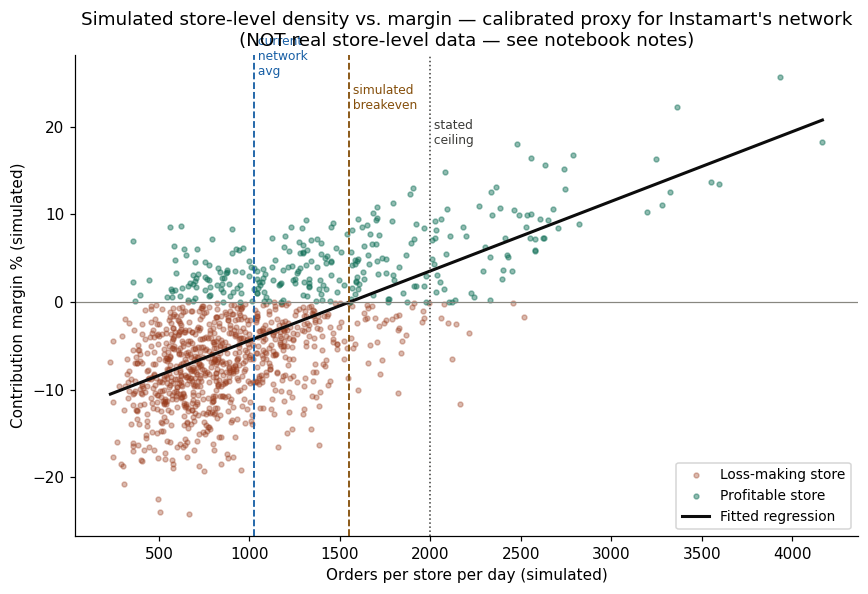

In [12]:

fig, ax = plt.subplots(figsize=(8, 5.5))
profitable_mask = store_df.contribution_margin_pct > 0
ax.scatter(store_df.loc[~profitable_mask, "orders_per_day"], store_df.loc[~profitable_mask, "contribution_margin_pct"],
           s=10, alpha=0.35, color="#993C1D", label="Loss-making store")
ax.scatter(store_df.loc[profitable_mask, "orders_per_day"], store_df.loc[profitable_mask, "contribution_margin_pct"],
           s=10, alpha=0.45, color="#0F6E56", label="Profitable store")

x_line = np.linspace(store_df.orders_per_day.min(), store_df.orders_per_day.max(), 100)
ax.plot(x_line, slope_fit * x_line + intercept_fit, color="#0C0C0C", linewidth=2, label="Fitted regression")

ax.axvline(TARGET_NETWORK_DENSITY, color="#185FA5", linestyle="--", linewidth=1.2)
ax.text(TARGET_NETWORK_DENSITY, ax.get_ylim()[1]*0.92, " current\n network\n avg", color="#185FA5", fontsize=8)
ax.axvline(breakeven_density, color="#854F0B", linestyle="--", linewidth=1.2)
ax.text(breakeven_density, ax.get_ylim()[1]*0.78, " simulated\n breakeven", color="#854F0B", fontsize=8)
ax.axvline(2000, color="#3B3B38", linestyle=":", linewidth=1)
ax.text(2000, ax.get_ylim()[1]*0.64, " stated\n ceiling", color="#3B3B38", fontsize=8)

ax.axhline(0, color="#888780", linewidth=0.8)
ax.set_xlabel("Orders per store per day (simulated)")
ax.set_ylabel("Contribution margin % (simulated)")
ax.set_title("Simulated store-level density vs. margin — calibrated proxy for Instamart's network\n(NOT real store-level data — see notebook notes)")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(PROCESSED / "b1_chart_simulated_density_margin_regression.png", bbox_inches="tight")
plt.show()


**Reading this properly:** at store-level granularity, density is — by construction
of this calibrated proxy — a strong, statistically significant predictor of margin
(that's what the simulation was built to test, so a strong R² here demonstrates the
method, not a new discovery). The genuinely useful output is the **breakeven density
estimate relative to the two real, disclosed numbers**: the current network average
(1,025) and the stated capacity ceiling (2,000+). If the real relationship inside
Instamart's network is even roughly similar in shape, the gap between today's average and
breakeven is the single number that should anchor the "how much density growth do we
actually need" conversation in the strategy deck — not a vague "grow density" recommendation.

**This section should be labeled in any slide deck as illustrative methodology on
proxy data, not as a finding about Instamart's real store economics.** The real,
defensible findings from this notebook are H1.1 (current density vs. ceiling) and H1.2
(profitable-store share) above, both built on company-disclosed numbers.


## Branch 1 summary

In [13]:

verdict = pd.DataFrame([
    dict(hypothesis_id="H1.1", hypothesis="Network density materially below breakeven/ceiling",
         verdict="Supported", evidence="Disclosed: 1,025 vs. stated 2,000+ ceiling (51% utilization)"),
    dict(hypothesis_id="H1.2", hypothesis="Loss concentrated in a minority of stores",
         verdict="Supported", evidence="Disclosed: only ~25% of stores profitable as of Q2 FY26"),
    dict(hypothesis_id="H1.3", hypothesis="New stores take 6-12mo to mature, dragging blended margin",
         verdict="Inconclusive — not testable", evidence="No public store-cohort/vintage data available"),
    dict(hypothesis_id="H1.4", hypothesis="Megapods improve throughput/margin via SKU breadth",
         verdict="Directionally supportive, quantitatively thin", evidence="Qualitative only — SKU count, ~50% of net adds"),
    dict(hypothesis_id="Cross-player regression (n=3)", hypothesis="Density alone explains the margin gap across companies",
         verdict="Weak/inconclusive", evidence="Zepto: highest density, near-worst loss. Blinkit: mid density, best loss by far — business model likely dominates"),
    dict(hypothesis_id="Simulated store-level regression", hypothesis="Density predicts margin within a single network",
         verdict="Methodology demonstrated on calibrated proxy data", evidence=f"R²={r_value**2:.2f} on n={n_stores} simulated stores; breakeven ≈ {breakeven_density:,.0f} orders/day"),
])
verdict.to_csv(PROCESSED / "b1_verdict_summary.csv", index=False)
verdict


,hypothesis_id,hypothesis,verdict,evidence
0,H1.1,Network density materially below breakeven/ceiling,Supported,"Disclosed: 1,025 vs. stated 2,000+ ceiling (51% utilization)"
1,H1.2,Loss concentrated in a minority of stores,Supported,Disclosed: only ~25% of stores profitable as of Q2 FY26
2,H1.3,"New stores take 6-12mo to mature, dragging blended margin",Inconclusive — not testable,No public store-cohort/vintage data available
3,H1.4,Megapods improve throughput/margin via SKU breadth,"Directionally supportive, quantitatively thin","Qualitative only — SKU count, ~50% of net adds"
4,Cross-player regression (n=3),Density alone explains the margin gap across companies,Weak/inconclusive,"Zepto: highest density, near-worst loss. Blinkit: mid density, best loss by far — busi..."
5,Simulated store-level regression,Density predicts margin within a single network,Methodology demonstrated on calibrated proxy data,"R²=0.41 on n=1143 simulated stores; breakeven ≈ 1,552 orders/day"
